# Quickstart

This quickstart walks through a complete **end-to-end neuraLQX simulation** for the toy $\mathrm{U}(1)$ BF-theory model in the weak coupling limit on a theta graph. We will consider the Euclidean constraint only, and the model lives in 2-spatial dimensions. In this quickstart, we will **not** work in the gauge invariant subspace, but the full kinematical space.

The goal of the quickkstart is not to teach every concept from scratch. Instead, it shows the workflow in the
same order you would run it in practice:

1. configure neuraLQX,
2. build a graph,
3. build a Hilbert space (and its gauge structure),
4. build an LQX model and select a constraint operator,
5. configure the solver (sampler + optimizer + network),
6. run VMC and monitor observables.

If you can run the script in this page, you have a functioning neuraLQX installation and you understand the
core "happy path" workflow.

## 0. Before you start

**What you need**

* A working Python environment with neuraLQX installed.
* A CPU installation is enough for this quickstart.
* Familiarity with JAX/NetKet helps, but is not required.

**What this run is doing**

We will:

* create a **planar** $\theta$-graph,
* define a full kinematical $\mathrm{U}(1)$ Hilbert space with cutoff $q_\mathrm{max}=2$ and gauge dimension 1,
* construct the Euclidean LQX model interface in 3D spacetime,
* choose the **BF-type** curvature constraint + Gauß constraint as our objective $\hat{\mathcal{Q}}$,
* train a neural quantum state with VMC to minimise $\langle \hat{\mathcal{Q}} \rangle$,
* monitor minimal loop holonomy observables during optimisation.


## 1. Imports

For this workflow you only need to import both neuraLQX and JAX. We will also need Matplotlib for plotting.

```{warning}
When using neuraLQX, you <b>must</b> import it <b>before importing NetKet or JAX</b>. neuraLQX internally may set some environment variables for both NetKet and JAX. If you import either one of them *before* neuraLQX, these variables will be ineffective, resulting in incorrect behaviour.
```

In [1]:
import neuralqx as nqx

import jax

import matplotlib.pyplot as plt

## 2. Build the graph

In neuraLQX, the graph is the discrete geometric backbone: it fixes the edge set, vertex set, orientation conventions, and the structure of many operators.

To build a planar graph in neuraLQX, you supply a list of oriented edges. Each edge is a tuple $(v_{out}, v_{in})$ where each vertex is labeled by an integer.

```{tip}
If you have multiple edges between the same vertices, you can distinguish them by inserting a key for each edge (i.e. $(v_{out}, v_{in}, \mathrm{key})$).
```

In [2]:
# create the edges of the graph
edges = [(0, 1), (0, 2), (0, 3), (3, 2), (1, 2)]

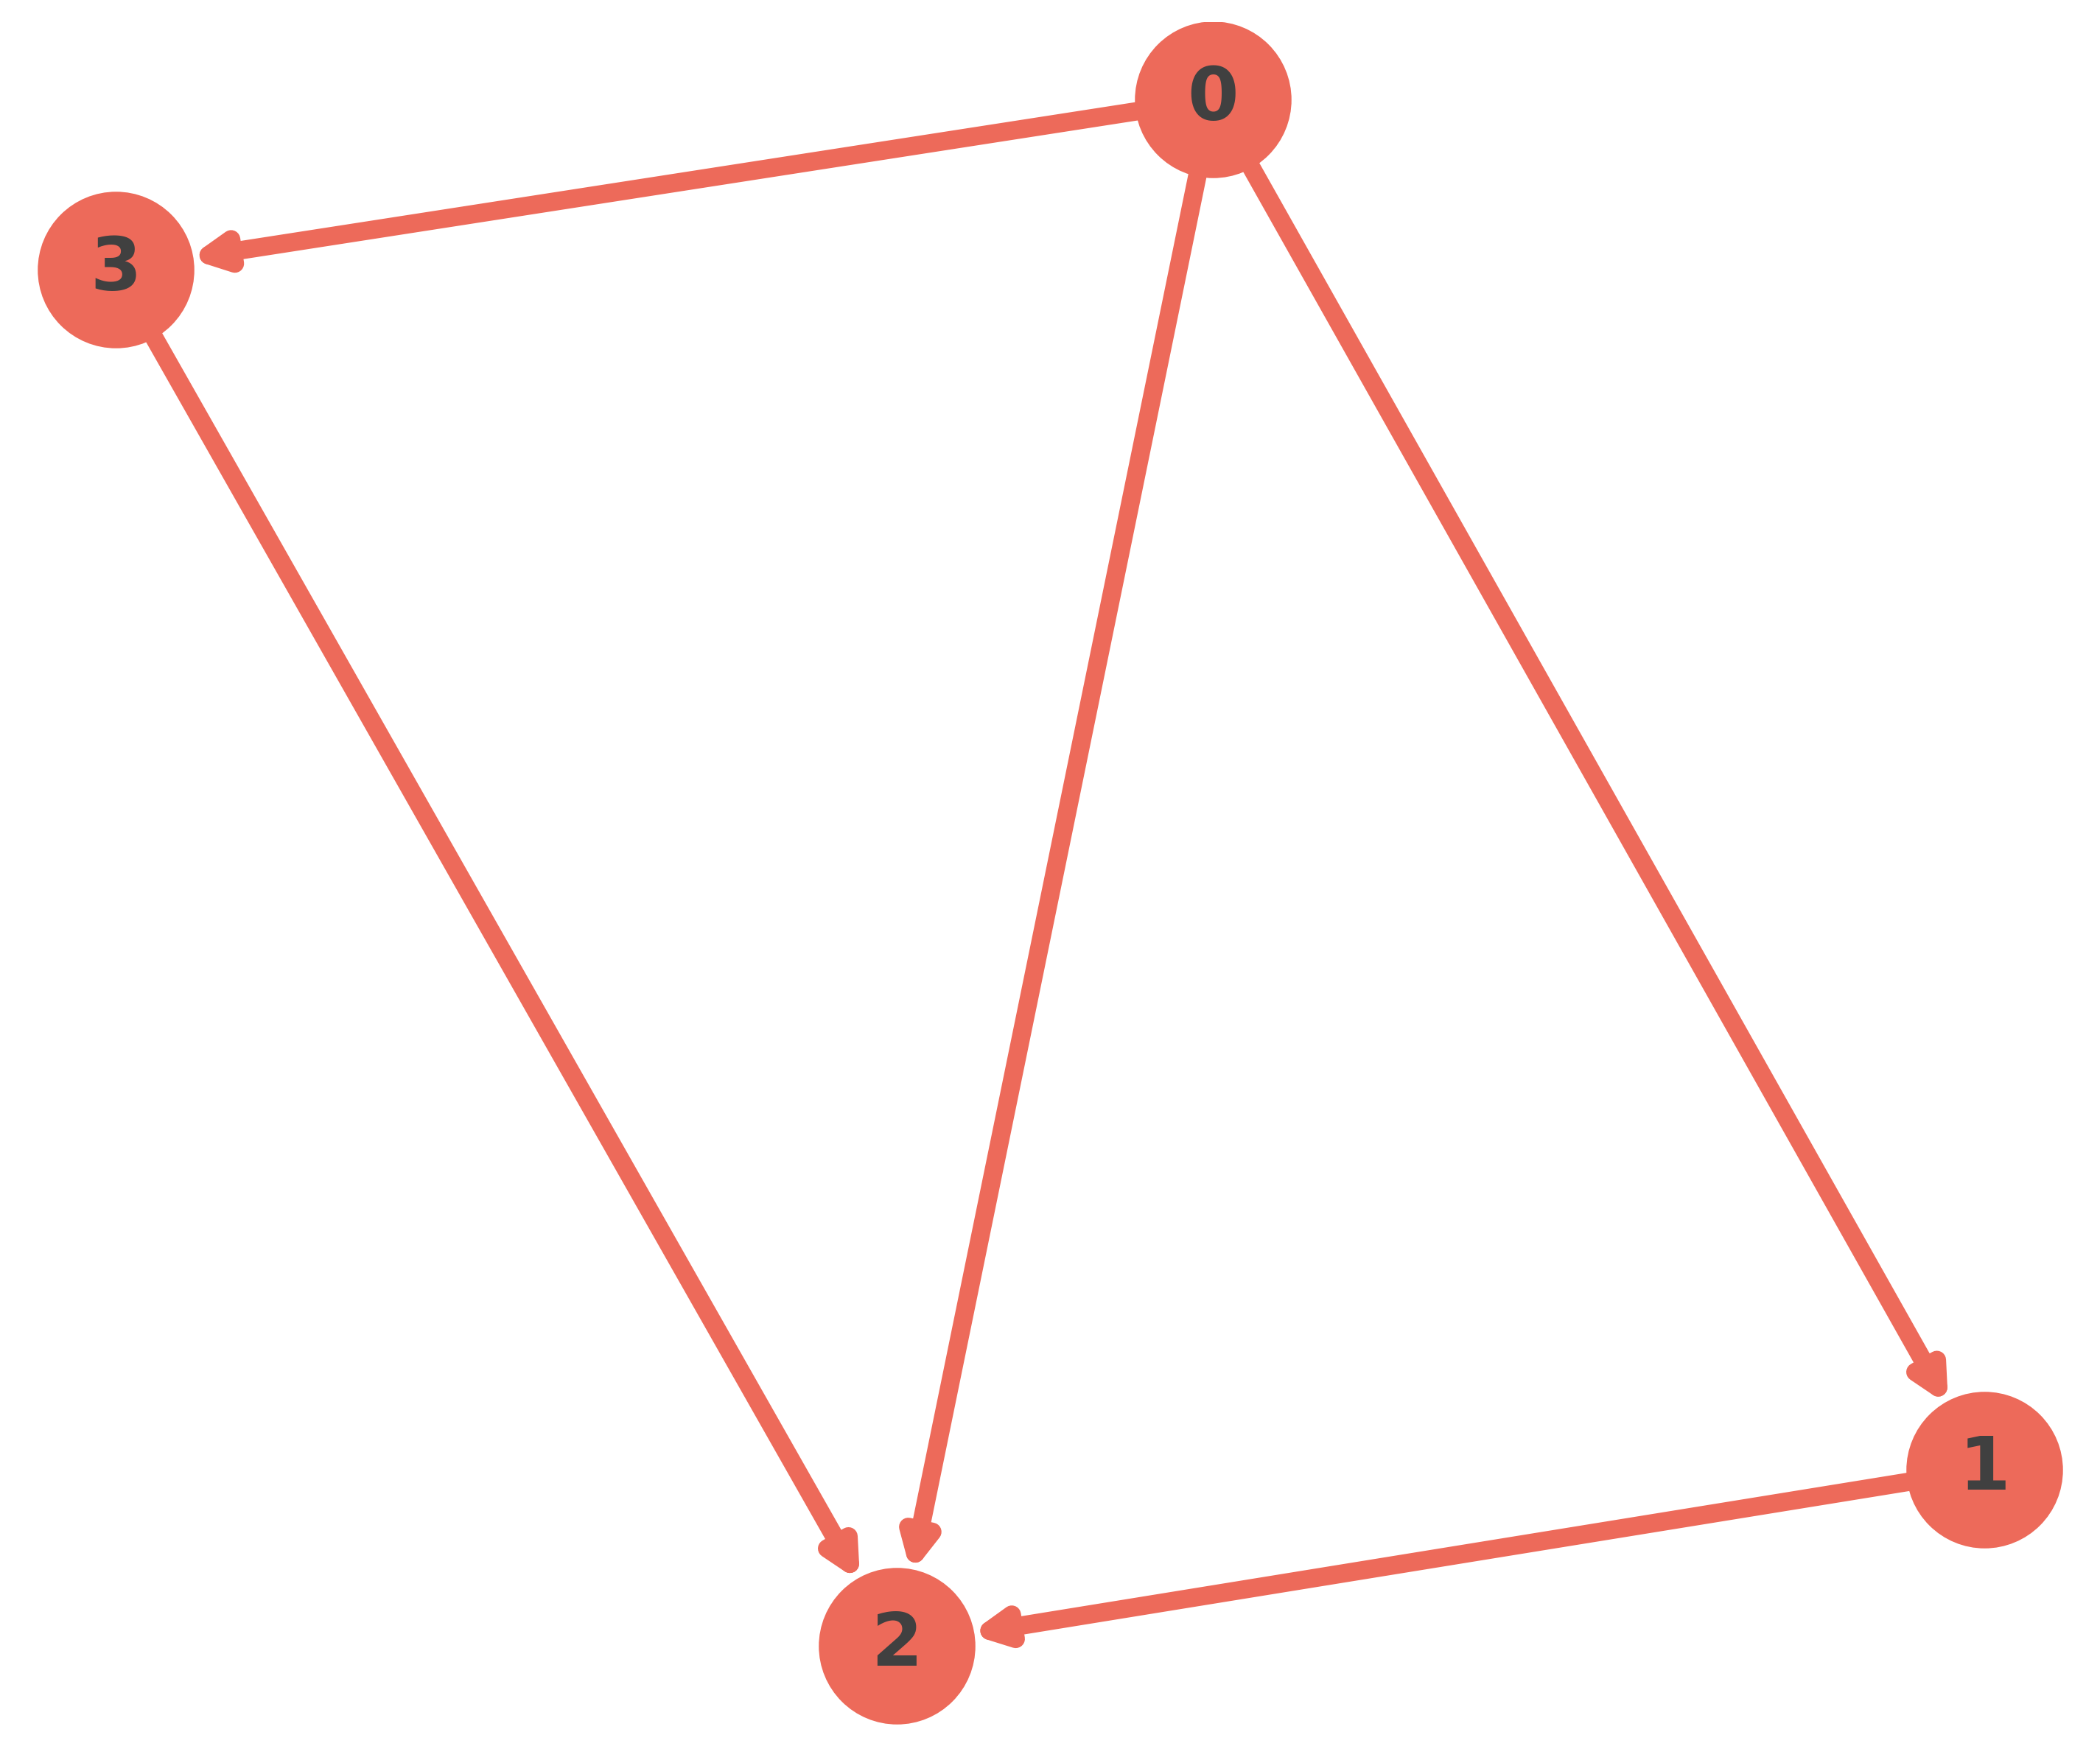

In [3]:
# create a graph
graph = nqx.graph.Graph(edges, plot = True)

In [4]:
# some information about the graph
graph

Graph(n_edges=5, n_vertices=4, n_minimal_loops=2, is_planar=True)

The graph object has a lot of static graph related attributes, such as minimal loops.

In [5]:
# look at the minimal loops
graph.minimal_loops()

[[(0, 2, 0), (2, 1, 0), (1, 0, 0)], [(0, 2, 0), (2, 3, 0), (3, 0, 0)]]

## 3. Define the Hilbert space

The Hilbert space specifies:

* the degrees of freedom (edge labels),
* the cutoff/truncation,
* and which symmetry constraints (such as gauge invariance) are going to be built into the kinematics.

Create a kinematical Hilbert space with $\mathrm{U}(1)$ degrees of freedom


In [6]:
H = nqx.hilbert.u1.HilbertU1(
    graph,
    cutoff=2,  # the q_max
    gauge_dimensions=1,  # since we use U(1) DOFs
)

In [7]:
# some information about the space
H

HilbertU1(dimensions=3.12 x 10³, cutoff=2, dofs=StaticRange(start=-2, step=1, length=5, dtype=int64), is_gauge_invariant=False, is_finite=True, is_indexable=True)

Here, `cutoff` controls the truncation of the edge labels. In a $\mathrm{U}(1)$ theory, edge labels behave like discrete integers in a bounded range determined by the cutoff.

The internal gauge dimension $N$ in $\mathrm{U}(1)^N$ is controlled by the `gauge_dimensions` parameter. Setting `gauge_dimensions=3` means each edge effectively carries three independent Abelian components.

## 4. Build the gauge group object

Imposing gauge invariance in neuraLQX is handled through a dedicated gauge group object that:

* encodes the local group action as an operator,
* provides group-related utility operations,
* and can be configured for lazy vs eager construction and for computational backends (JAX, etc.).

In [8]:
# create a U(1) gauge group
G = nqx.gauge_groups.u1.U1GaugeGroup(
    H,
    computational=True,  # use fast, memory friendly operator types
    jax=True,  # use the faster JAX implementation of such operators
)

In [9]:
# some information about the group
G

U1GaugeGroup(dimensions=1, hilbert=HomogeneousHilbert(local_size=5, N=5), is_abelian=True, is_computational=True)

## 5. Create the LQX Euclidean model interface

The LQX module is the physics-facing interface: it ties together:

* Hilbert space,
* gauge group,
* model choice (Euclidean, spherical, QRLG),
* and exposes the corresponding constraints and operators.

The gauge dimensions are inferred from the gauge group and Hilbert objects, and the relevant operators are constructed based on that, as well as the specified spacetime dimensions.

In [10]:
# create a U(1) BF-theory model, in the weak coupling limit
lqx = nqx.lqx.LqxWCL(
    H,
    G,
    spacetime_dimensions=3,  # work in 2-spatial dimensions
    computational=True,  # work with lightweight, fast operators
)

In [11]:
# some information about the physical model
lqx

LqxWCL(gauge_invariant_model=False, hilbert_dimensions=3.12 x 10³, gauge_dimensions=1, model_name=U(1) BF-Theory, spacetime_dimensions=3, is_computational=True)

**Depending on your physical model**, at this point you have should have a model object that can generate operators related to your specific chosen model, such as:

* volume operators,
* curvature constraints,
* Hamiltonian/Thiemann-style constraints,
* and model-specific composite objects.

The object $\hat{\mathcal{Q}}$ which will be solved for is stored in the `lqx.constraint` attribute. This is conceptually important: it is where you decide what your optimisation is *trying to solve*.

* You are not "minimising an energy" in the traditional condensed-matter sense.
* You are training a variational state to make $\langle \hat{\mathcal{Q}}\rangle$ small, where $\hat{\mathcal{Q}}$ encodes the Euclidean Hamiltonian constraint structure (in the chosen truncation / discretisation / model).

If you later switch to a different constraint, penalty structure, or projector, this is one of the first places you will modify.

If the model is small enough, as in this case, you can also perform exact diagonalisation to get a ground truth and compare the VMC result later.


In [12]:
# obtain the "ground state" and corresponding "ground energy"
lqx.exact_diagonalization()

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Minimum eigenvalue using Lanczos algorithm: 0.6011650770653008                                    │
│   Timestamp:  2026-02-05 18:09:51                                                                               │
│                                                                                                                 │
╰────────────────────────────────────────── Logged by LqxWCL._lanczos() ──────────────────────────────────────────╯

## 6. Create the solver

The solver orchestrates:

* sampling (chains, sweeps, machine_pow),
* optimisation (optimizer, SR/diag shift),
* neural network state initialisation,
* runtime logs and plotting/export.

In [13]:
# create the solver
solver = nqx.solver.Solver(
    lqx,
    output_path="TEST_RUN",  # where output data should be solved
    seed = 0,  # a seed to initialise the neural network and sampling process
)

## 7. Configure the sampler

Sampling is the engine of VMC. The sampler produces configurations distributed according to the current variational state. neuraLQX offers a lot of samplers, some native to NetKet, some implemented to specific needs of neuraLQX. Now, we will work with a sampler with no rejection methods, i.e. using exact inference, and therefore no Markov chains.


In [14]:
solver.set_sampler(
    sampler_type="Exact Sampler",
    number_of_samples=450,
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Sampler `Exact Sampler` initialized.                                                              │
│   Timestamp:  2026-02-05 18:09:52                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_sampler() ─────────────────────────────────────────╯

## 8. Configure the optimizer

neuraLQX exposes optimizers through the solver configuration, and typically couples them with SR/QGT-style preconditioning controlled via a diagonal shift.

In [15]:
solver.set_optimizer(
    optimizer_type="sgd",  # use stochastic gradient descent
    learning_rate=0.004,
    use_sr=True,  # use stochastic reconfiguration (SR)
    diagonal_shift=0.1,  # diagonal shift for the SR
)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Optimizer `sgd` initialized.                                                                      │
│   Timestamp:  2026-02-05 18:09:52                                                                               │
│                                                                                                                 │
╰─────────────────────────────────────── Logged by Solver.set_optimizer() ────────────────────────────────────────╯

## 9. Build the neural quantum state

Now define the variational ansatz. In this example we use a variant of the `RevNet` models from neuraLQX, but you can choose any Flax based network.

In [16]:
# create the network
model = nqx.nn.models.RevNetAuto(
    number_of_cnn_features=30,
    lqx=lqx,
    rng_key=jax.random.PRNGKey(0),
)

In [17]:
# set it in the solver
solver.set_network(model)

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Network `RevNetOld` initialized.                                                                  │
│   Timestamp:  2026-02-05 18:09:52                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.set_network() ─────────────────────────────────────────╯

At this point, after you later call `solver.run(...)`, the solver will:

* initialise network parameters,
* create an `MCState` with the configured sampler,
* build a driver targeting `lqx.constraint`,
* and begin optimisation.

## 10. Define observables to monitor

Besides the primary constraint expectation, you often want to track physically meaningful observables. Here we monitor the minimal loop holonomy operators on both minimal loops.

In [18]:
observables = {
    "MLH_0": lqx.minimal_loop_holonomy(graph.dressed_minimal_loops()[0]),
    "MLH_1": lqx.minimal_loop_holonomy(graph.dressed_minimal_loops()[1]),
}

Observables are evaluated during training and appear in the runtime log. They are also useful for diagnosing:

* whether the state is collapsing into trivial configurations,
* whether the solver is discovering structure at specific vertices,
* and whether constraint minimisation correlates with curvature/volume behaviour.


## 11. Run the simulation

Finally run VMC:

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Starting simulation                                                                               │
│               Observables: ['MLH_0', 'MLH_1']                                                                   │
│   Timestamp:  2026-02-05 18:09:52                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver._prepare_run() ────────────────────────────────────────╯

  0%|          | 0/1000 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 6.016                                                                                                    │
│ ├── (41.2%) | MCState.expect_and_grad : 2.476 s                                                                 │
│ │   └── (21.5%) | MCState.sample : 0.532 s                                                                      │
│ ├── (38.1%) | AbstractLinearPreconditioner.__call__ : 2.295 s                                                   │
│ │   ├── (10.0%) | QGTOnTheFly_DefaultConstructor : 0.231 s                                                      │
│ │   └── (88.2%) | LinearOperator.solve : 2.025 s                                                                │
│ ├── (12.2%) | estimate observables : 0.734 s                                                                    │
│ │   └── (97.6%) | MCState.expect : 0.716 s                            

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    State serialised to disc.                                                                         │
│   Timestamp:  2026-02-05 18:09:59                                                                               │
│                                                                                                                 │
╰──────────────────────────────────────── Logged by Solver.export_state() ────────────────────────────────────────╯

╭─────────────────────────────────────────────── neuraLQX Printer ────────────────────────────────────────────────╮
│                                                                                                                 │
│   Message:    Data exported to disk.                                                                            │
│   Timestamp:  2026-02-05 18:09:59                                                                               │
│                                                                                                                 │
╰───────────────────────────────────── Logged by Logger.write_log_to_file() ──────────────────────────────────────╯

╭────────────── neuraLQX Output Log 18:09:59 - 05.02.2026 (hash:3bc89f-9cf325344c) (seed:0) v1.0.0 ───────────────╮
│                                                                                                                 │
│   Optimization Results:   ╭─────────────────────────────────────────────────────────────────────────────────╮   │
│                           │                                                                                 │   │
│                           │   Exact diagonalization result:                      0.6011650770653008         │   │
│                           │   Network result:                                    0.659 ± 0.013 [σ²=0.082]   │   │
│                           │   Average min<C> over last 100 iterations            0.652(0.003)               │   │
│                           │   (stddev):                                                                     │   │
│                           │   Average R_Hat over last 100 iterations (stddev):   nan(nan)                   │   │
│                           │                                                                                 │   │
│                           ╰─────────────────────────────────────────────────────────────────────────────────╯   │
│   Network Configs:        ╭─────────────────────────────────────────────────────────────────────────────────╮   │
│                           │                                                                                 │   │
│                           │   Network type:                        RevNetOld                                │   │
│                           │   Number of network parameters:        781                                      │   │
│                           │   RevNetAuto.number_of_cnn_features:   30                                       │   │
│                           │   RevNetAuto.rng_key:                  [0 0]                                    │   │
│                           │   RevNetAuto.lqx:                      LqxWCL(gauge_invariant_model=False,      │   │
│                           │                                        hilbert_dimensions=3.12 x 10³,           │   │
│                           │                                        gauge_dimensions=1, model_name=U(1)      │   │
│                           │                                        BF-Theory, spacetime_dimensions=3,       │   │
│                           │                                        is_computational=True)                   │   │
│                           │   RevNetAuto.dropout_rate:             0.2                                      │   │
│                           │   RevNetAuto.free_idxs:                None                                     │   │
│                           │   RevNetAuto.dtype:                    float64                                  │   │
│                           │   Params(network) / dim(Hilbert):      2.4992 x 10¹ %                           │   │
│                           │                                                                                 │   │
│                           ╰─────────────────────────────────────────────────────────────────────────────────╯   │
│   Optimizer Configs:      ╭─────────────────────────────────────────────────────────────────────────────────╮   │
│                           │                                                                                 │   │
│                           │   Learning rate:               0.004                                            │   │
│                           │   Number of iterations:        1000                                             │   │
│                           │   Diagonal shift:              0.1                                              │   │
│                           │   Optimizer:                   SGD                                              │   │
│                           │   Optimizer param: momentu

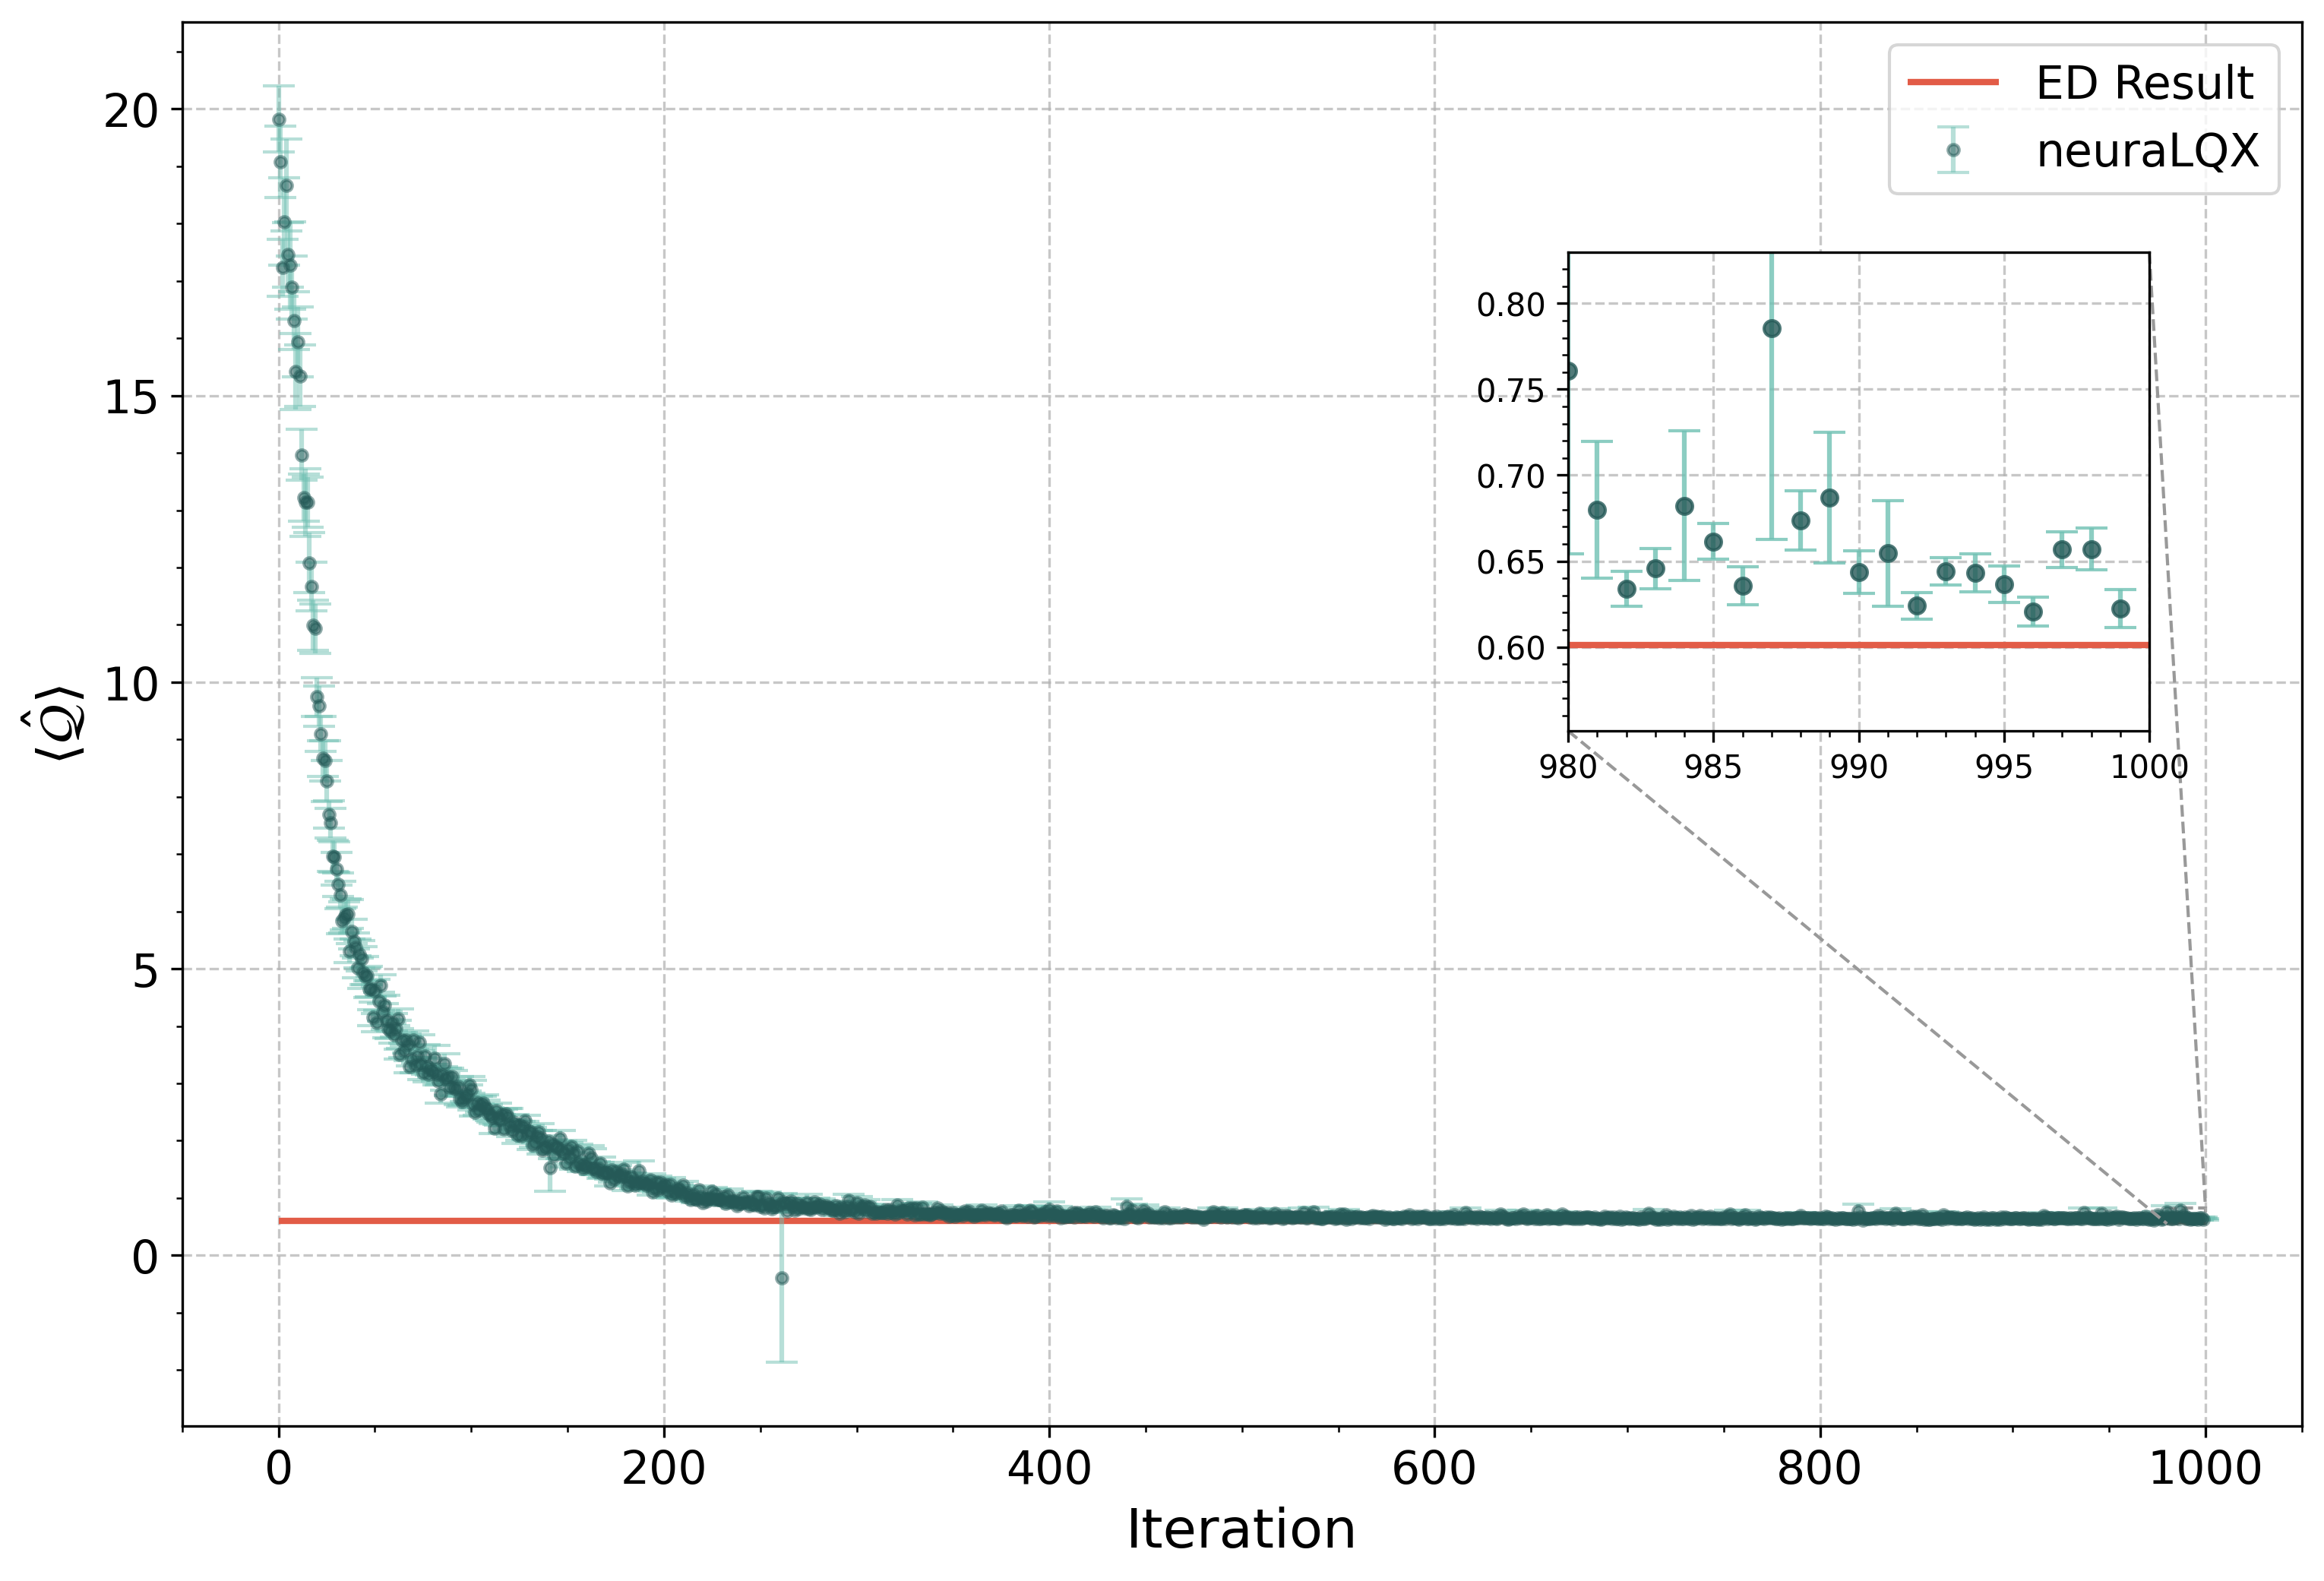

In [19]:
solver.run(
    n_iters=1000,  # number of VMC iterations
    observables=observables,  # observables to monitor
    timer=True,  # output NetKet timing metrics
    silent_plot=False,  # produce a plot of the minimisation after the loop is completed
    live_monitoring=False,  # disable live monitoring
)

What happens during ``run`` (conceptual overview):

1. A sampling phase generates configurations from the current variational state.
2. The solver estimates $\langle \hat{\mathcal{Q}} \rangle$ and its gradient w.r.t. network parameters.
3. SR/QGT preconditioning (with diagonal shift) transforms the gradient into a stable update direction (if requested).
4. The optimizer applies an update step (SGD here).
5. Observables are evaluated and logged.
6. The loop repeats for 1000 iterations.

In this case, the whole process over 100 iterations took only a bit over 6 seconds!

```{tip}
If live monitoring is enabled, you can see the constraint curve evolve during optimisation in real time.
```

## 12. Plot the observables

We can now plot the observables we monitored during the optimisation

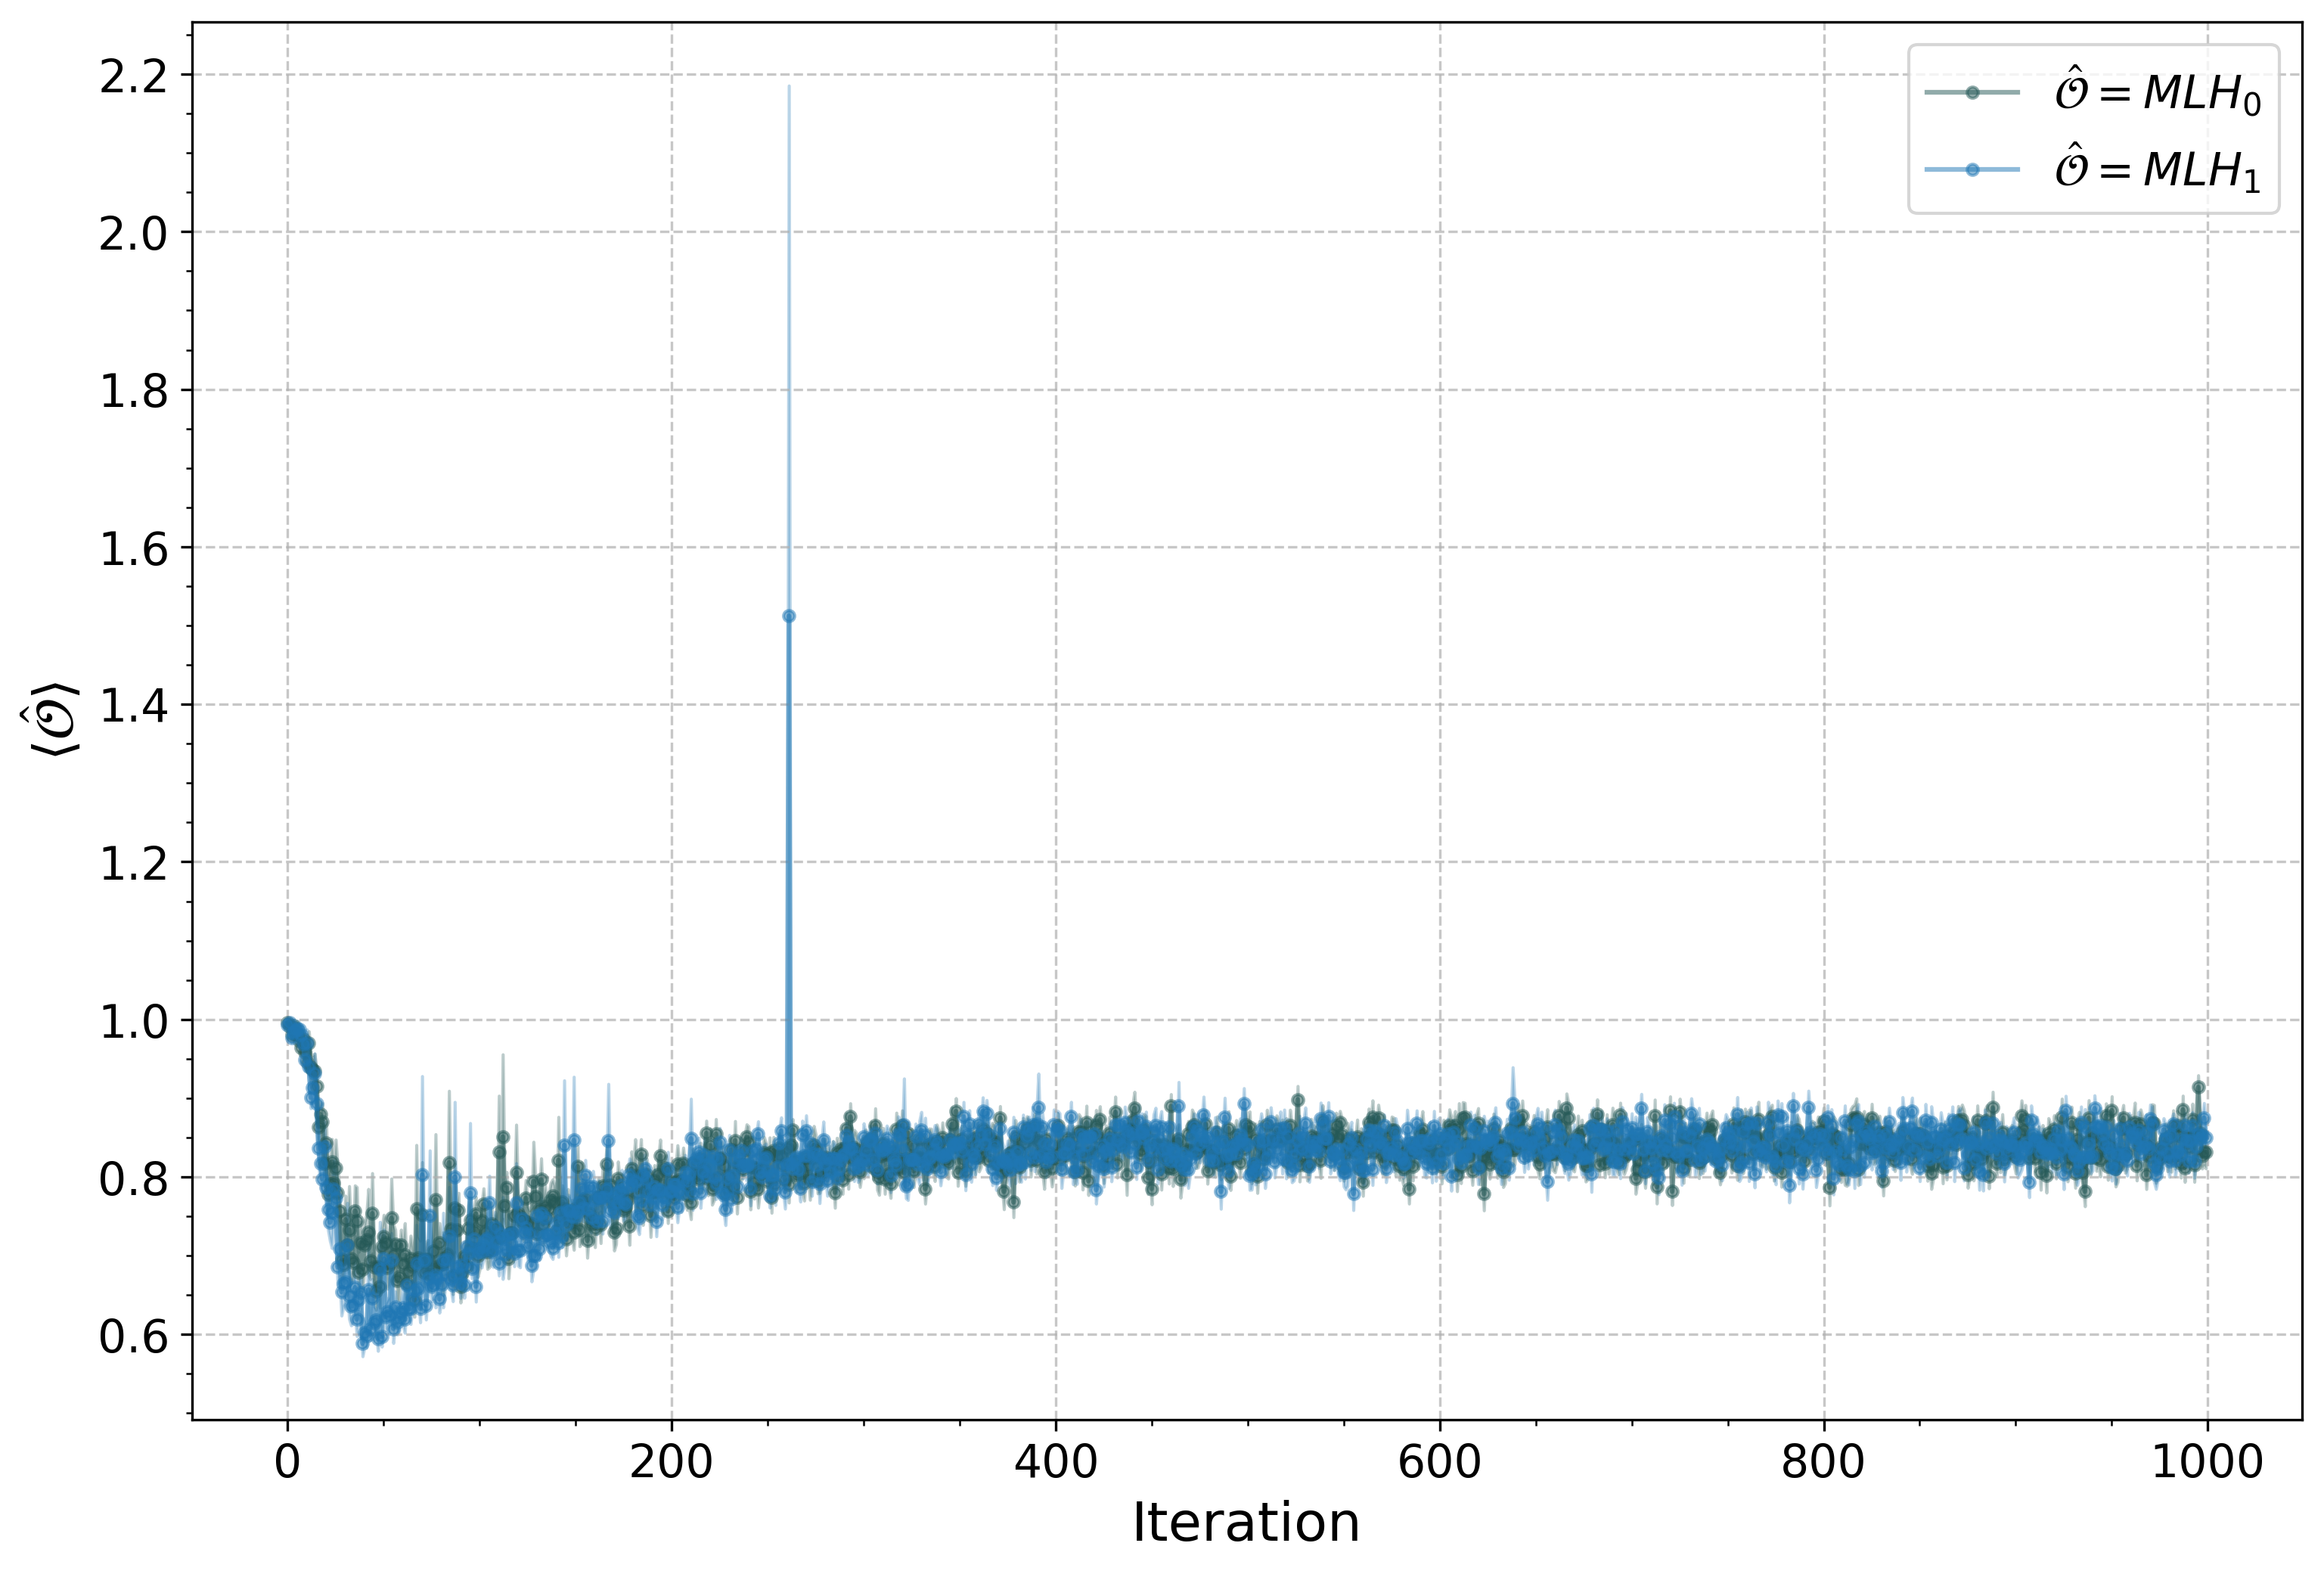

In [20]:
solver.plot_observables("MLH_0", "MLH_1")

As we see, the minimal loop holonomies are tending to 1, but not quite. Therefore, the solutions we are getting are almost flat, but not exactly.

## 13. Compare with exact diagonalisation

Since the model is small enough, the state can be held completely in memory, which means we can plot all its amplitudes

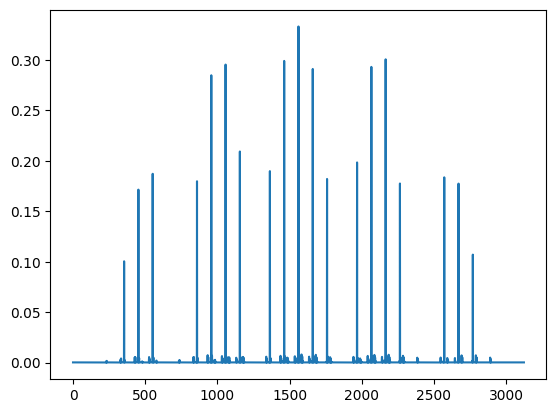

In [21]:
# plot all amplitudes from the neural network (i.e. VMC optimised state)
plt.plot(solver.variational_state.to_array())

And now compare from the "ground state" we obtained before the simulations

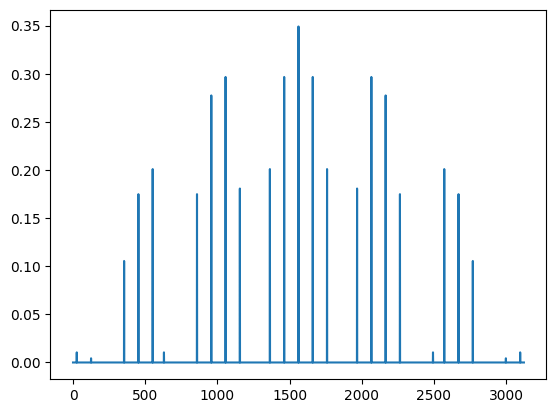

In [22]:
plt.plot(lqx.ground_state)

Which show they are almost identically the same! We can also compute the overlap:

In [23]:
jax.numpy.abs(jax.numpy.vdot(lqx.ground_state, solver.variational_state.to_array()))**2

Array(0.9924801, dtype=float64)

It comes out almost identical, which means that our VMC obtained state has an overlap of over 99% with the state obtained through exact diagonalisation, even though we have used only 25% of the dimensions of the Hilbert space as network parameters!

## 14. Check the constraints

We can also check whether the curvature constraint is more satisfied than the Gauß constraint

In [24]:
# compute the expectation value of the curvature constraint
solver.expect(lqx.curvature_constraint())

0.6455 ± 0.0093 [σ²=0.0414]

In [25]:
# compute the expectation value of the Gauß constraint
solver.expect(G.constraint)

0.0133 ± 0.0074 [σ²=0.0265]

As we see, the state satisfies the Gauß constraint more than it does the curvature constraint.

## 15. Next steps

Once you can run this quickstart successfully, the natural next steps are:

* Read guides to understand the building blocks more deeply (graphs, Hilbert spaces, gauge groups, operators).
* Switch to a different graph (lattice graphs, custom graphs) and compare convergence.
* Explore different constraints (Gauss/master forms, alternative operator backends).
* Use projectors and penalties (see the projectors/penalties guides) to enforce additional structure.

A good practical next page after this one is the solver guide, because it explains logging, exporting states, and how to structure larger experiments.

